python -m venv venv
venv\Scripts\activate
pip install numpy matplotlib tensorflow scikit-learn
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
pip install notebook
python -m notebook

Write Python program to implement CNN object detection. Discuss numerous performance
evaluation metrics for evaluating the object-detecting algorithms' performance.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

In [35]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

print(f'Train : {x_train.shape} Test : {x_test.shape}')
print(f'Image shape : {x_train[0].shape} Pixel range : [0, 255]')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 45s 0us/step


C:\A-Projects-gng\practicals\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train : (50000, 32, 32, 3) Test : (10000, 32, 32, 3)
Image shape : (32, 32, 3) Pixel range : [0, 255]


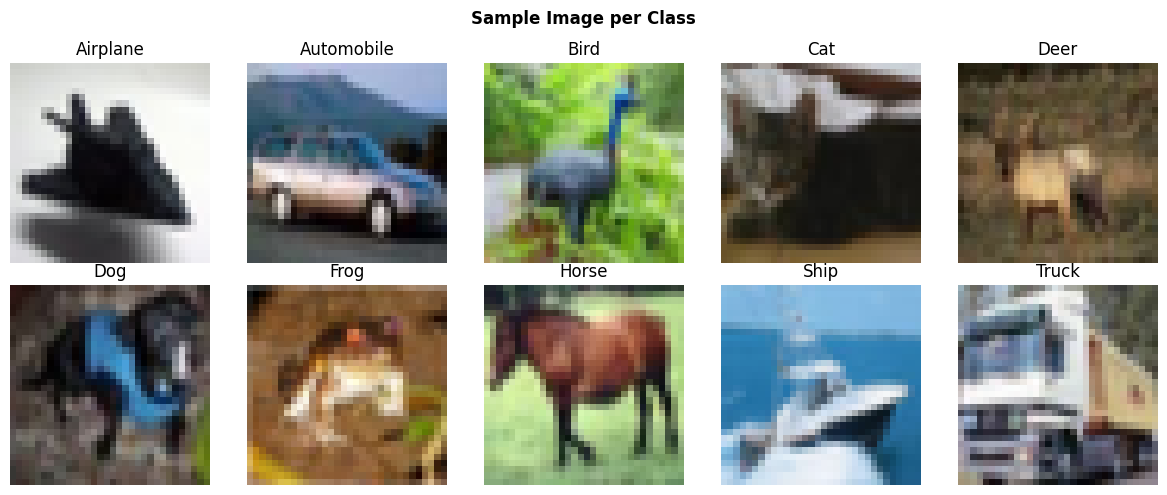

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    idx = np.where(y_train.flatten() == i)[0][0]
    axes[i//5, i%5].imshow(x_train[idx])
    axes[i//5, i%5].set_title(class_names[i])
    axes[i//5, i%5].axis('off')

plt.suptitle('Sample Image per Class', fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
x_train_n = x_train.astype('float32') / 255.0
x_test_n = x_test.astype('float32') / 255.0

In [38]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\A-Projects-gng\practicals\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape               ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                    │ (None, 30, 30, 32)         │            896 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ max_pooling2d (MaxPooling2D)       │ (None, 15, 15, 32)         │              0 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ conv2d_1 (Conv2D)                  │ (None, 13, 13, 64)         │         18,496 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ max_pooling2d_1 (MaxPooling2D)     │ (None, 6, 6, 64)           │              0 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ flatten (Flatten)                  │ (None, 2304)               │              0 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dense (Dense)                      │ (None, 64)                 │        147,520 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dense_1 (Dense)                    │ (None, 10)                 │            650 │
└────────────────────────────────────┴────────────────────────────┴────────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(
    x_train_n, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.4425 - loss: 1.5479 - val_accuracy: 0.5542 - val_loss: 1.2685
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.5762 - loss: 1.2015 - val_accuracy: 0.6034 - val_loss: 1.1472
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6281 - loss: 1.0644 - val_accuracy: 0.6392 - val_loss: 1.0343
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6557 - loss: 0.9809 - val_accuracy: 0.6716 - val_loss: 0.9684
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6822 - loss: 0.9166 - val_accuracy: 0.6548 - val_loss: 0.9923


In [40]:
loss, acc = model.evaluate(x_test_n, y_test, verbose=0)

print(f'Test Accuracy : {acc:.4f}')
print(f'Test Loss : {loss:.4f}')

Test Accuracy : 0.6423
Test Loss : 1.0305


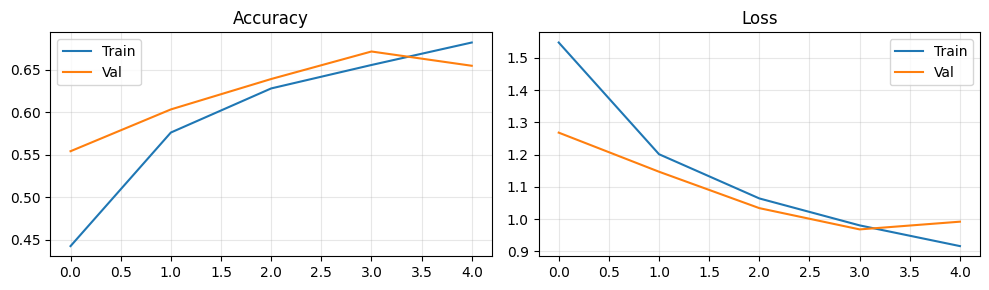

In [41]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3))

a1.plot(history.history['accuracy'], label='Train')
a1.plot(history.history['val_accuracy'], label='Val')
a1.set_title('Accuracy')
a1.legend()
a1.grid(alpha=.3)

a2.plot(history.history['loss'], label='Train')
a2.plot(history.history['val_loss'], label='Val')
a2.set_title('Loss')
a2.legend()
a2.grid(alpha=.3)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

    Airplane       0.70      0.68      0.69      1000
  Automobile       0.82      0.76      0.79      1000
        Bird       0.54      0.54      0.54      1000
         Cat       0.38      0.64      0.48      1000
        Deer       0.67      0.48      0.56      1000
         Dog       0.51      0.60      0.56      1000
        Frog       0.88      0.57      0.69      1000
       Horse       0.78      0.67      0.72      1000
        Ship       0.67      0.81      0.74      1000
       Truck       0.81      0.66      0.73      1000

    accuracy                           0.64     10000
   macro avg       0.68      0.64      0.65     10000
weighted avg       0.68      0.64      0.65     10000



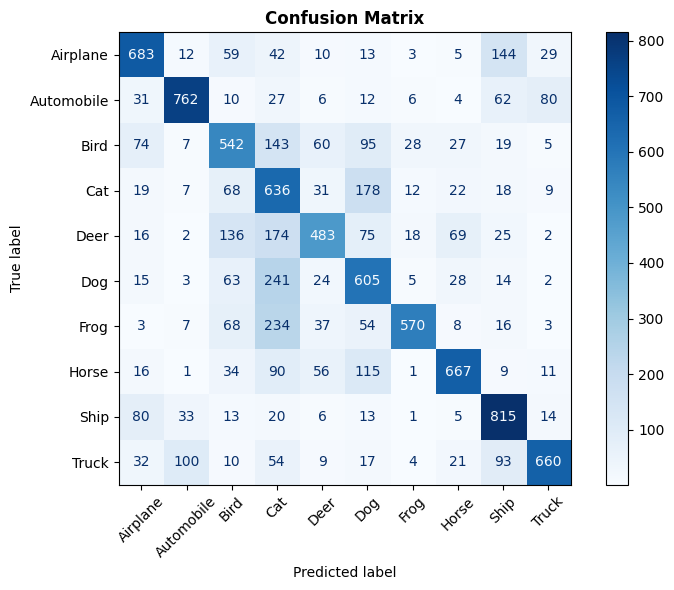

In [42]:
y_pred = np.argmax(model.predict(x_test_n, verbose=0), axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', xticks_rotation=45
)

ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

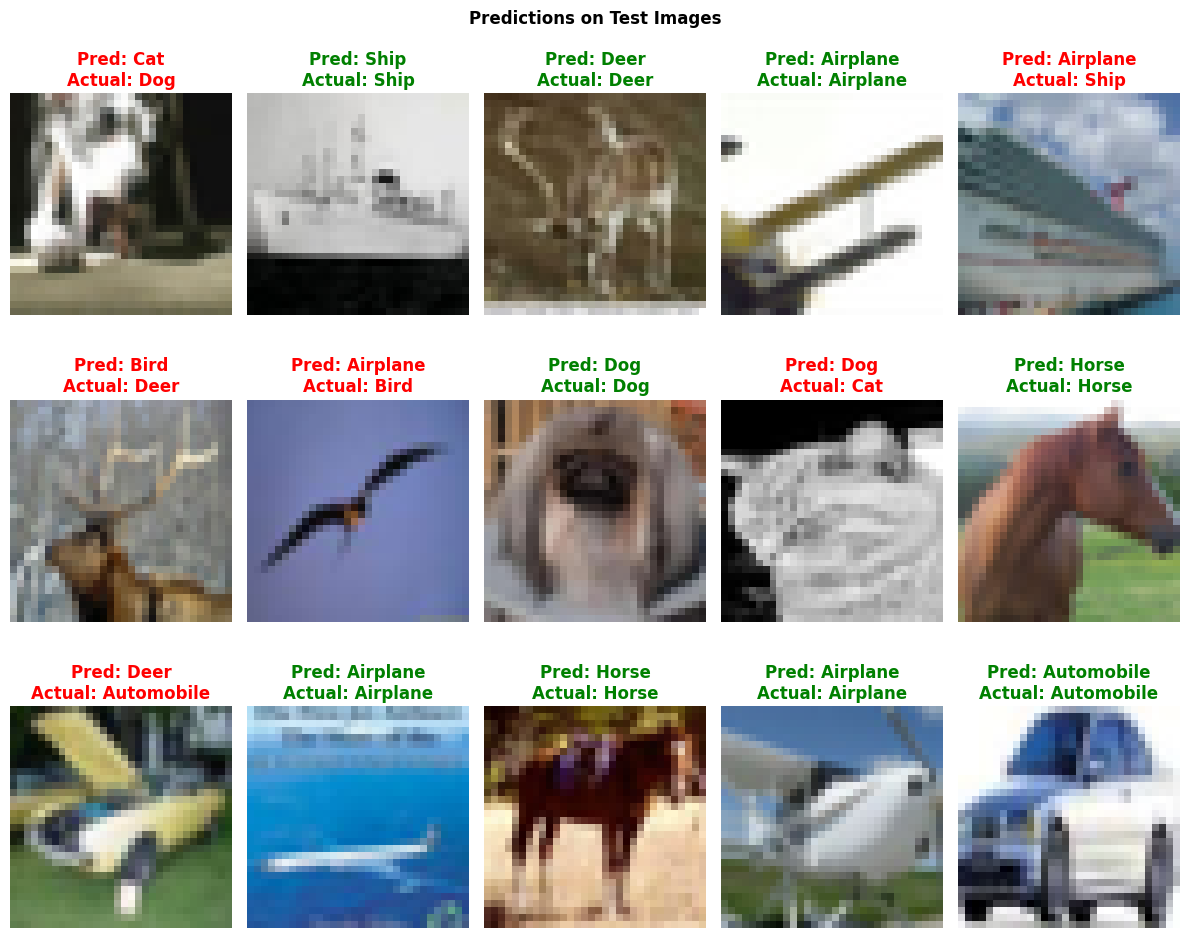

In [43]:
fig, axes = plt.subplots(3, 5, figsize=(12, 10))

for i in range(15):
    idx = np.random.randint(0, len(x_test_n))
    ax = axes[i//5, i%5]
    ax.imshow(x_test_n[idx])

    predicted_class = class_names[y_pred[idx]]
    actual_class = class_names[y_true[idx]]

    color = 'green' if y_pred[idx] == y_true[idx] else 'red'

    ax.set_title(f'Pred: {predicted_class}\nActual: {actual_class}',
                 color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Predictions on Test Images', fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
def compute_iou(b1, b2):
    xi1, yi1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    xi2, yi2 = min(b1[2], b2[2]), min(b1[3], b2[3])

    inter = max(0, xi2-xi1) * max(0, yi2-yi1)

    union = ((b1[2]-b1[0])*(b1[3]-b1[1]) +
             (b2[2]-b2[0])*(b2[3]-b2[1]) - inter)

    return inter / union if union > 0 else 0

gt_box = [50, 50, 200, 200]
pred_box = [60, 55, 210, 195]

iou = compute_iou(gt_box, pred_box)

print("Ground Truth:", gt_box)
print("Prediction:", pred_box)
print(f"IoU: {iou:.4f}")

Ground Truth: [50, 50, 200, 200]
Prediction: [60, 55, 210, 195]
IoU: 0.8201


In [45]:
single = x_test_n[0:1]

_ = model.predict(single, verbose=0)

t0 = time.time()
for _ in range(20):
    model.predict(single, verbose=0)

avg = (time.time() - t0) / 20

print(f'Average latency : {avg*1000:.2f} ms')
print(f'Approximate FPS : {1/avg:.2f}')

Average latency : 138.79 ms
Approximate FPS : 7.21
